# Resume Shortlister Dataset Exploration

This notebook loads the main `candidates.jsonl` dataset, shows a complete sample candidate record, and visualizes the dataset structure.


In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

DATA_DIR = Path('.')
CANDIDATES_PATH = DATA_DIR / 'candidates.jsonl'
SAMPLE_CANDIDATES_PATH = DATA_DIR / 'sample_candidates.json'
SUBMISSION_PATH = DATA_DIR / 'sample_submission.csv'

def load_candidates_jsonl(path: Path) -> pd.DataFrame:
    return pd.read_json(path, lines=True)

def load_sample_candidates(path: Path) -> pd.DataFrame:
    with path.open('r', encoding='utf-8') as f:
        return pd.DataFrame(json.load(f))

def load_submission_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)

def flatten_candidate_fields(df: pd.DataFrame) -> pd.DataFrame:
    profile_df = pd.json_normalize(df['profile']).add_prefix('profile.')
    redrob_df = pd.json_normalize(df['redrob_signals']).add_prefix('redrob.')
    return pd.concat([df[['candidate_id']], profile_df, redrob_df], axis=1)

def nested_counts(df: pd.DataFrame) -> pd.DataFrame:
    counts = pd.DataFrame({'candidate_id': df['candidate_id']})
    counts['num_skills'] = df['skills'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    counts['num_career_history_entries'] = df['career_history'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    counts['num_education_entries'] = df['education'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    counts['num_certifications'] = df['certifications'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    counts['num_languages'] = df['languages'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    return counts


In [2]:
candidates_df = load_candidates_jsonl(CANDIDATES_PATH)
sample_candidates_df = load_sample_candidates(SAMPLE_CANDIDATES_PATH)
submission_df = load_submission_csv(SUBMISSION_PATH)

print('candidates.jsonl shape:', candidates_df.shape)
print('sample_candidates.json shape:', sample_candidates_df.shape)
print('sample_submission.csv shape:', submission_df.shape)
print('candidates.jsonl columns:', candidates_df.columns.tolist())
print('sample_submission columns:', submission_df.columns.tolist())


candidates.jsonl shape: (100000, 8)
sample_candidates.json shape: (50, 8)
sample_submission.csv shape: (100, 4)
candidates.jsonl columns: ['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals']
sample_submission columns: ['candidate_id', 'rank', 'score', 'reasoning']


## Complete sample candidate record

This cell prints one full candidate record with nested fields so you can inspect the exact JSON structure.


In [3]:
sample_record = candidates_df.iloc[0].to_dict()
print(json.dumps(sample_record, indent=2, ensure_ascii=False))


{
  "candidate_id": "CAND_0000001",
  "profile": {
    "anonymized_name": "Ira Vora",
    "headline": "Backend Engineer | SQL, Spark, Cloud",
    "summary": "Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid — Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side — Python, SQL, Spark, Airflow, warehouse design — and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I can leverage my existing data-infra skills while learning modern ML practice.",
    "location": "Toronto",
    "country": "Canada",
    "years_of_experience": 6.9,
    "current_title": "Backend Engineer",
    "current_company": "Mindtree",
    "current_company_size": "10001+",
    "cu

## Flattened top-level candidate fields

Flattening `profile` and `redrob_signals` makes it easier to inspect candidate-level features in a table.


In [4]:
flat_candidates = flatten_candidate_fields(candidates_df)
flat_candidates.head(5)


,candidate_id,profile.anonymized_name,profile.headline,profile.summary,profile.location,profile.country,profile.years_of_experience,profile.current_title,profile.current_company,profile.current_company_size,profile.current_industry,redrob.profile_completeness_score,redrob.signup_date,redrob.last_active_date,redrob.open_to_work_flag,redrob.profile_views_received_30d,redrob.applications_submitted_30d,redrob.recruiter_response_rate,redrob.avg_response_time_hours,redrob.connection_count,redrob.endorsements_received,redrob.notice_period_days,redrob.preferred_work_mode,redrob.willing_to_relocate,redrob.github_activity_score,redrob.search_appearance_30d,redrob.saved_by_recruiters_30d,redrob.interview_completion_rate,redrob.offer_acceptance_rate,redrob.verified_email,redrob.verified_phone,redrob.linkedin_connected,redrob.skill_assessment_scores.NLP,redrob.skill_assessment_scores.Image Classification,redrob.skill_assessment_scores.Fine-tuning LLMs,redrob.skill_assessment_scores.Speech Recognition,redrob.expected_salary_range_inr_lpa.min,redrob.expected_salary_range_inr_lpa.max,redrob.skill_assessment_scores.GANs,redrob.skill_assessment_scores.OpenCV,redrob.skill_assessment_scores.Prompt Engineering,redrob.skill_assessment_scores.Object Detection,redrob.skill_assessment_scores.Recommendation Systems,redrob.skill_assessment_scores.FAISS,redrob.skill_assessment_scores.Weights & Biases,redrob.skill_assessment_scores.Forecasting,redrob.skill_assessment_scores.LangChain,redrob.skill_assessment_scores.YOLO,redrob.skill_assessment_scores.PEFT,redrob.skill_assessment_scores.Data Science,redrob.skill_assessment_scores.MLflow,redrob.skill_assessment_scores.Pinecone,redrob.skill_assessment_scores.Feature Engineering,redrob.skill_assessment_scores.BentoML,redrob.skill_assessment_scores.MLOps,redrob.skill_assessment_scores.Qdrant,redrob.skill_assessment_scores.CNN,redrob.skill_assessment_scores.Kubeflow,redrob.skill_assessment_scores.Machine Learning,redrob.skill_assessment_scores.Reinforcement Learning,redrob.skill_assessment_scores.Sentence Transformers,redrob.skill_assessment_scores.Haystack,redrob.skill_assessment_scores.Hugging Face Transformers,redrob.skill_assessment_scores.Semantic Search,redrob.skill_assessment_scores.LoRA,redrob.skill_assessment_scores.Diffusion Models,redrob.skill_assessment_scores.Milvus,redrob.skill_assessment_scores.Time Series,redrob.skill_assessment_scores.Statistical Modeling,redrob.skill_assessment_scores.Elasticsearch,redrob.skill_assessment_scores.Information Retrieval,redrob.skill_assessment_scores.Vector Search,redrob.skill_assessment_scores.Learning to Rank,redrob.skill_assessment_scores.ASR,redrob.skill_assessment_scores.TensorFlow,redrob.skill_assessment_scores.LLMs,redrob.skill_assessment_scores.Computer Vision,redrob.skill_assessment_scores.TTS,redrob.skill_assessment_scores.Weaviate,redrob.skill_assessment_scores.RAG,redrob.skill_assessment_scores.Python,redrob.skill_assessment_scores.OpenSearch,redrob.skill_assessment_scores.BM25,redrob.skill_assessment_scores.scikit-learn,redrob.skill_assessment_scores.pgvector,redrob.skill_assessment_scores.Embeddings,redrob.skill_assessment_scores.LlamaIndex,redrob.skill_assessment_scores.PyTorch,redrob.skill_assessment_scores.Deep Learning,redrob.skill_assessment_scores.QLoRA
0,CAND_0000001,Ira Vora,"Backend Engineer | SQL, Spark, Cloud","Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid — Spark, Airflow, SQL warehouses are hom...",Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,IT Services,86.9,2025-10-16,2026-05-20,True,23,2,0.34,177.8,356,35,60,onsite,False,9.2,249,4,0.71,0.58,True,True,False,38.8,64.8,41.6,53.7,18.7,36.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CAND_0000002,Saanvi Sethi,Op

## Nested array counts

This shows how many skills, career-history entries, education entries, certifications, and languages each candidate has.


In [5]:
counts_df = nested_counts(candidates_df)
counts_df.head(10)
counts_df.describe()


,num_skills,num_career_history_entries,num_education_entries,num_certifications,num_languages
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.0
mean,9.60302,3.001710,1.397780,0.374840,2.0
std,3.31163,1.522442,0.489442,0.696046,0.0
min,5.00000,1.000000,1.000000,0.000000,2.0
25%,7.00000,2.000000,1.000000,0.000000,2.0
50%,9.00000,3.000000,1.000000,0.000000,2.0
75%,11.00000,4.000000,2.000000,0.000000,2.0
max,23.00000,9.000000,2.000000,3.000000,2.0


## Visualizing distributions

The charts below help you understand dataset distributions quickly.


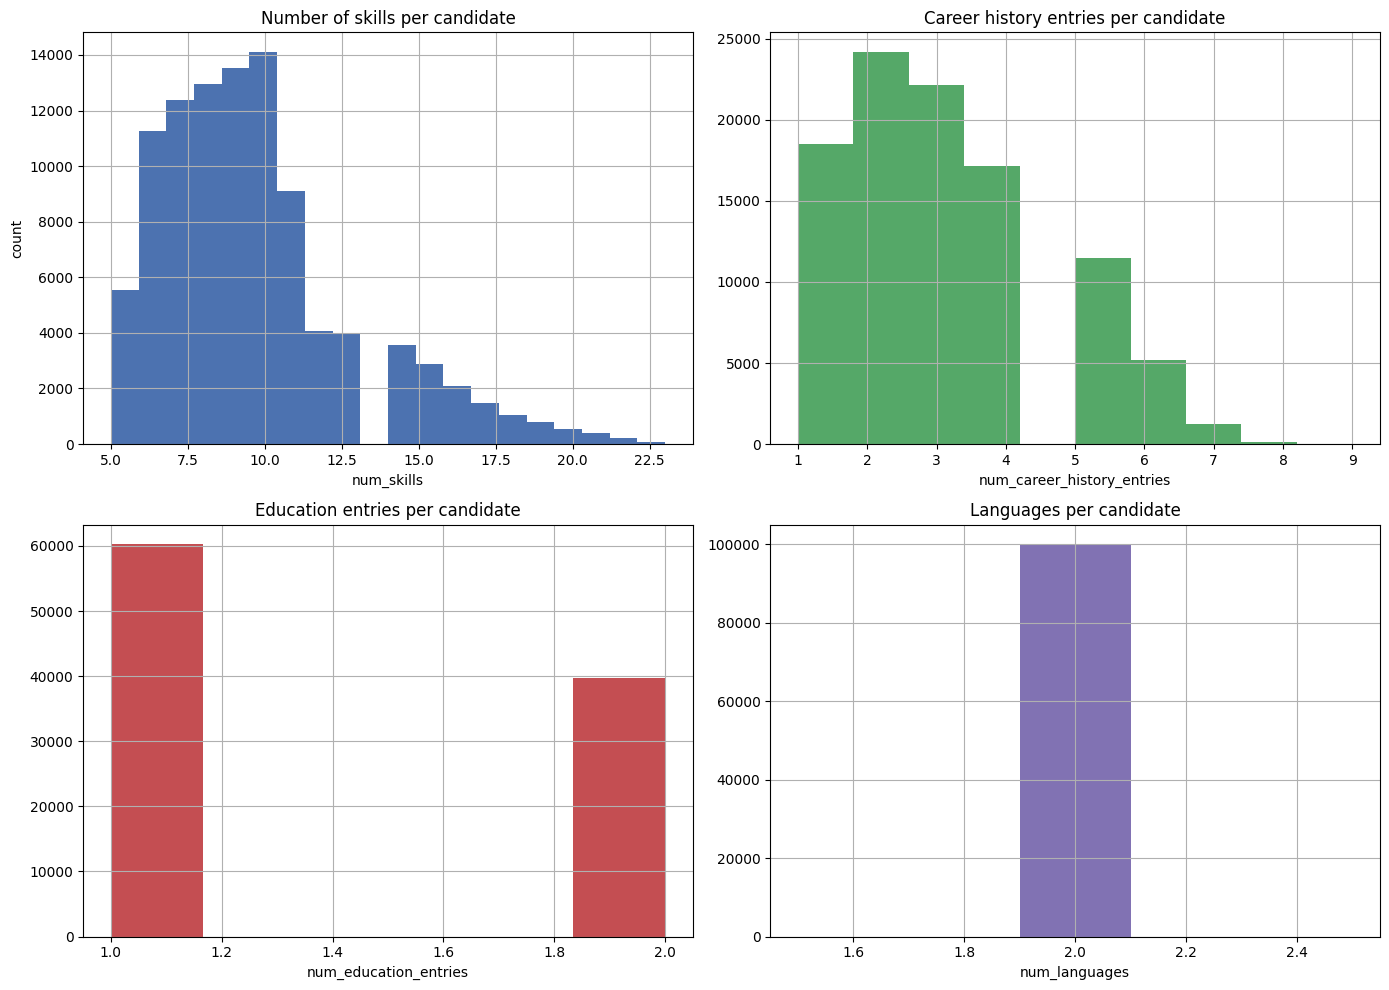

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
counts_df['num_skills'].hist(ax=axes[0, 0], bins=20, color='#4C72B0')
axes[0, 0].set_title('Number of skills per candidate')
axes[0, 0].set_xlabel('num_skills')
axes[0, 0].set_ylabel('count')
counts_df['num_career_history_entries'].hist(ax=axes[0, 1], bins=10, color='#55A868')
axes[0, 1].set_title('Career history entries per candidate')
axes[0, 1].set_xlabel('num_career_history_entries')
counts_df['num_education_entries'].hist(ax=axes[1, 0], bins=6, color='#C44E52')
axes[1, 0].set_title('Education entries per candidate')
axes[1, 0].set_xlabel('num_education_entries')
counts_df['num_languages'].hist(ax=axes[1, 1], bins=5, color='#8172B3')
axes[1, 1].set_title('Languages per candidate')
axes[1, 1].set_xlabel('num_languages')
plt.tight_layout()
plt.show()


## Sample submission preview

This shows the expected prediction output format for candidate ranking.


In [7]:
submission_df.head(10)


,candidate_id,rank,score,reasoning
0,CAND_0004989,1,0.992,HR Manager with 6.1 yrs; 9 AI core skills; response rate 0.76.
1,CAND_0001195,2,0.984,HR Manager with 8.7 yrs; 9 AI core skills; response rate 0.20.
2,CAND_0003114,3,0.976,ML Engineer with 6.4 yrs; 4 AI core skills; response rate 0.88.
3,CAND_0000339,4,0.968,Content Writer with 8.3 yrs; 8 AI core skills; response rate 0.72.
4,CAND_0001082,5,0.960,HR Manager with 5.0 yrs; 8 AI core skills; response rate 0.62.
5,CAND_0001218,6,0.952,Graphic Designer with 10.4 yrs; 9 AI core skills; response rate 0.56.
6,CAND_0004558,7,0.944,Business Analyst with 5.1 yrs; 8 AI core skills; response rate 0.54.
7,CAND_0001753,8,0.936,Content Writer with 8.3 yrs; 8 AI core skills; response rate 0.53.
8,CAND_0001503,9,0.928,Marketing Manager with 8.0 yrs; 8 AI core skills; response rate 0.32.
9,CAND_0004548,10,0.920,HR Manager with 7.3 yrs; 8 AI core skills; response rate 0.30.
